## Eval Lung

In [1]:
import torch
import scvi

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# NOTE: this has to be imported first :D... otehrwise GPUs will not be detected
import jax
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


In [4]:
from anndata import read_h5ad

import sys
sys.path.append("../../scripts")
from run_benchmark_pipeline import get_adata_path
from benchmark_pipeline import OBSM_KEYS, bluishgray_to_blue, gray_to_red, plot_results_table, blue_cmap, red_cmap, plot_metric_by_split
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

In [5]:
## Pertmute Extra
import numpy as np
import torch
np.random.seed(0)
torch.manual_seed(0)

## Read Data

In [6]:
dataset_base_path = "/data2/a330d/datasets/cosmx/lung"
dataset_name = "lung_cosmx"

In [7]:
adata = read_h5ad(get_adata_path(dataset_base_path, dataset_name))

In [8]:
# NOTE: Double Check that this is counts!
adata.X.max()

np.float32(365.0)

In [9]:
OBSM_KEYS = list(set(adata.obsm.keys()) & set(OBSM_KEYS))
print(OBSM_KEYS)

['Cellina_Shifted', 'Cellina_Basal', 'scVI', 'scVIVA', 'Cellina_Spatial', 'SCANVI']


In [10]:
batch_key = adata.uns['default_params']['batch_key']
celltype_key = adata.uns['default_params']['celltype_key']
niche_key = adata.uns['default_params']['niche_key']

In [11]:
from numpy.random import default_rng
rng = default_rng(0)
if adata.n_obs > 100_000:
    adata = adata[rng.choice(adata.n_obs, 100_000, replace=False)].copy()

## scIB

In [12]:
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=celltype_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm.benchmark()

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/6 [00:00<?, ?it/s]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:

In [13]:
# bm.get_results().to_csv('scib_ct.csv')
basal_df = bm.get_results()
basal_df = basal_df.rename({"Bio conservation": "Cell-type Total"}, axis=1)
basal_df.to_csv(f"../../results/{dataset_name}_scib_ct.csv")

## Niche

In [15]:
bm_niche = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=niche_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm_niche.benchmark()

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Embeddings:   0%|          | 0/6 [00:00<?, ?it/s]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  17%|█▋        | 1/6 [08:01<40:09, 481.99s/it]2026-01-23 22:01:08.348279: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-23 22:01:09.759044: W externa

In [16]:
omega_df = bm_niche.get_results(min_max_scale=False, clean_names=True)
omega_df = omega_df.rename({"Bio conservation":"Niche Total"}, axis=1)

omega_df.to_csv(f"../../results/{dataset_name}_scib_niche.csv")

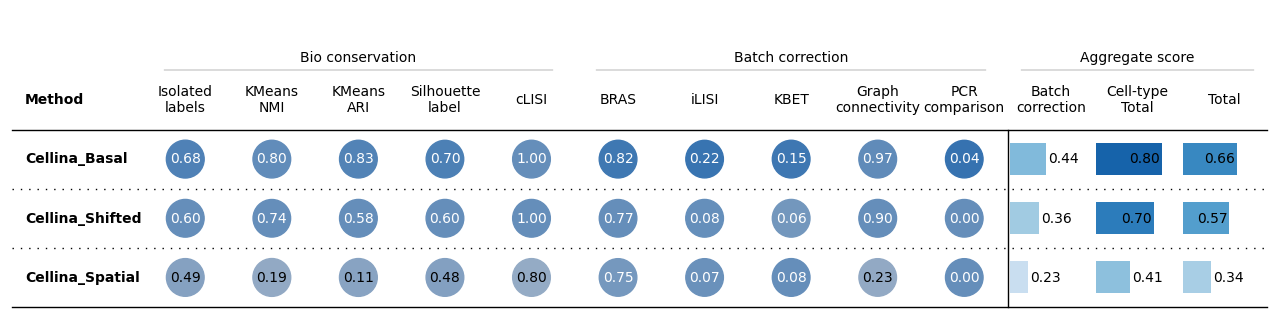

In [15]:
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'

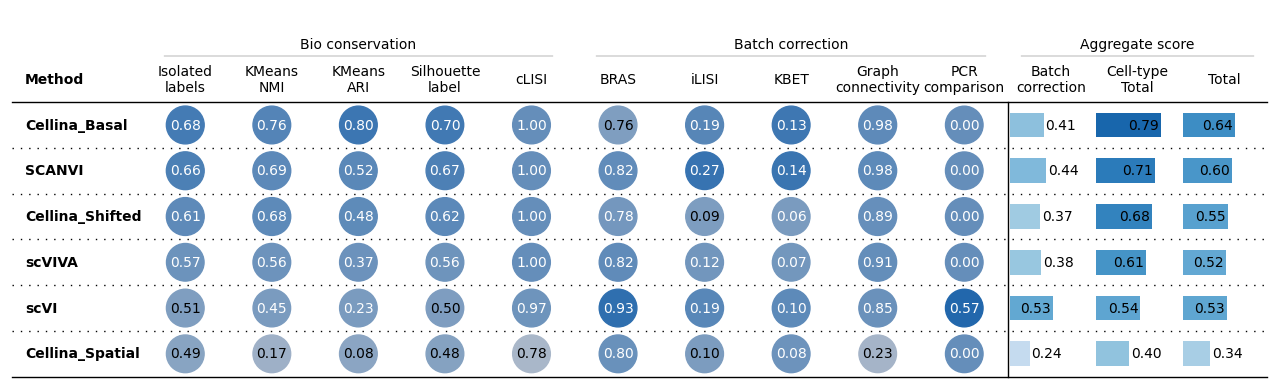

In [ ]:
# Lambdas = 1e-7
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'

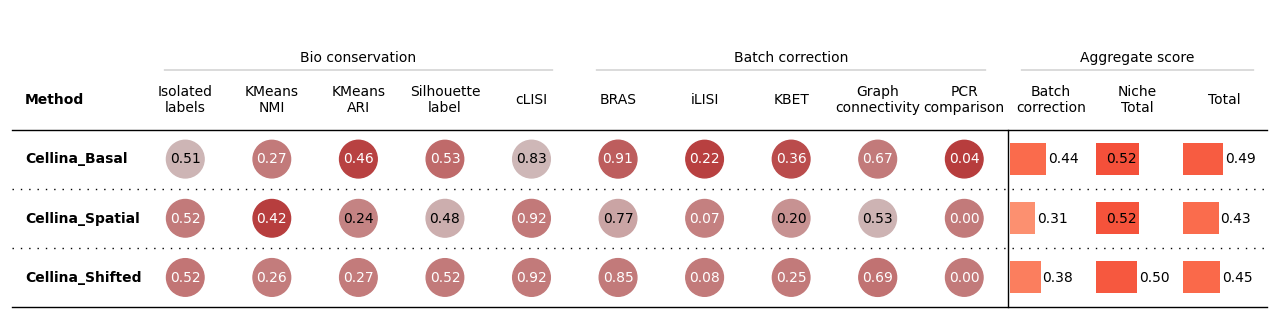

In [18]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

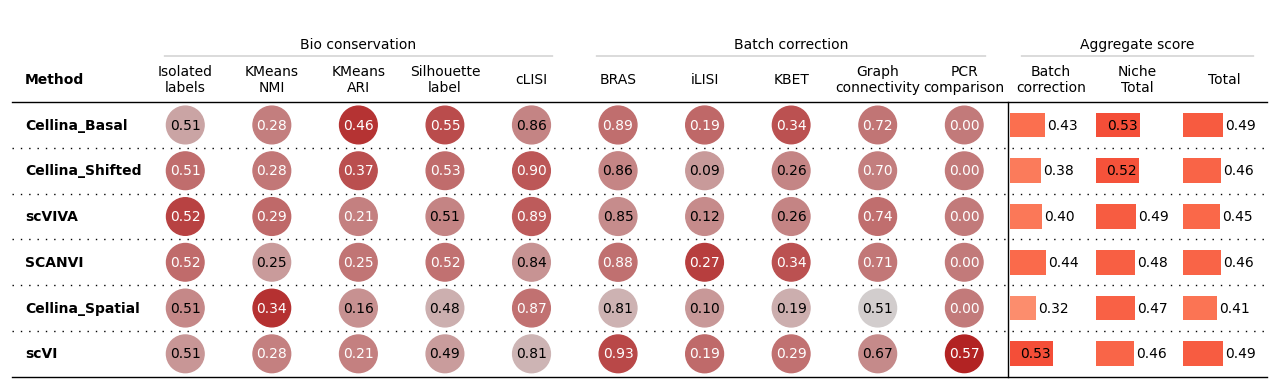

In [17]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


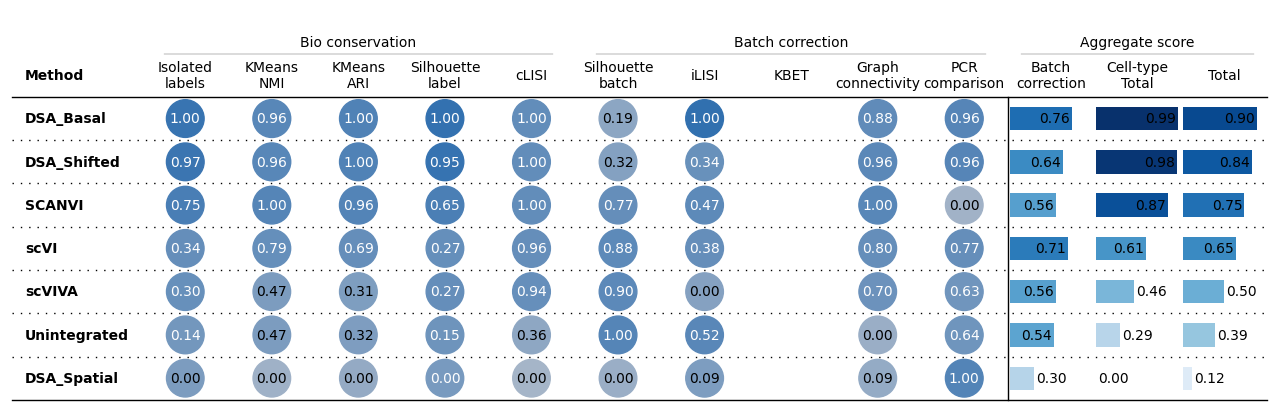

In [14]:

plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'


/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


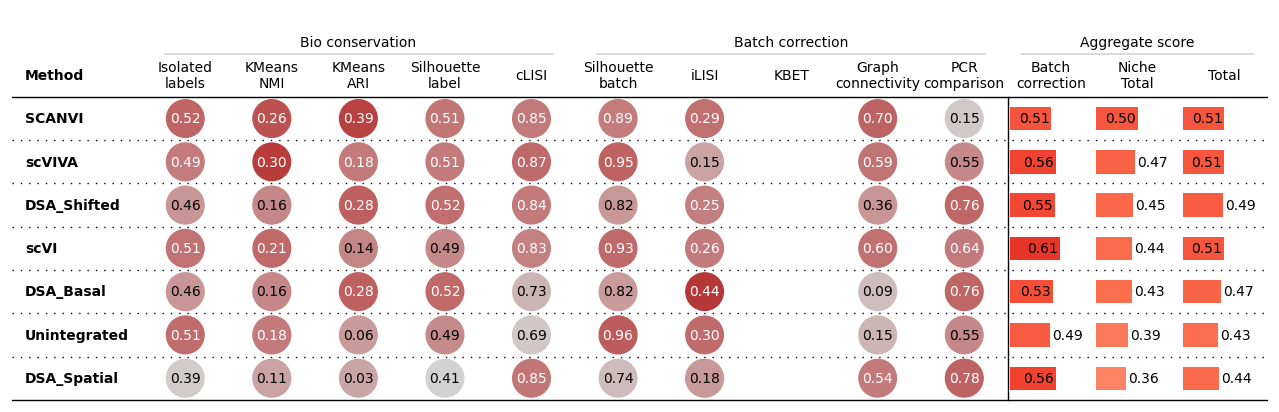

In [15]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

## OOD Classification

In [16]:
import pandas as pd
import scanpy as sc

from dsa.benchmarking.metrics import benchmark_latents_from_anndata

pd.set_option("display.max_columns", None)

In [17]:
niche_results = benchmark_latents_from_anndata(adata,
                                            label_key=niche_key,
                                            model_keys=OBSM_KEYS,
                                            n_bootstrap=100)
niche_results.to_csv(f"../results/{dataset_name}_class_niche.csv")

Benchmarking DSA_Shifted...


/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Benchmarking DSA_Spatial...
Benchmarking Unintegrated...
Benchmarking DSA_Basal...


/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Benchmarking SCANVI...


/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Benchmarking scVIVA...
Benchmarking scVI...


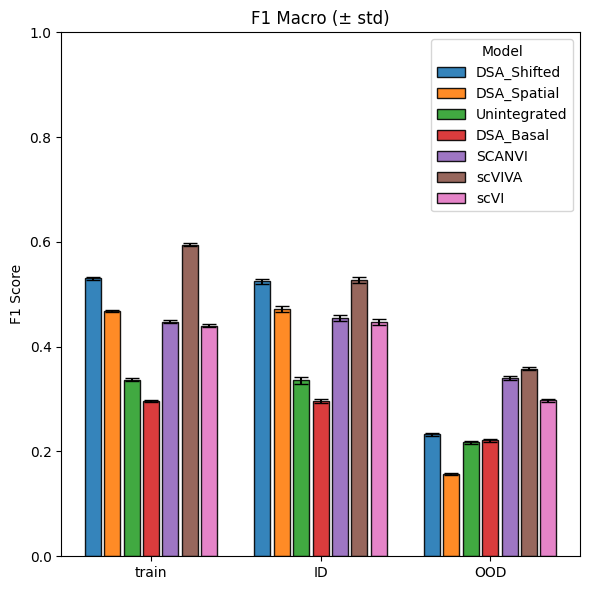

In [18]:
plot_metric_by_split(
    niche_results,
    metric="f1_macro",
    title="",
    ylabel="F1 Score",
    # palette=gray_to_red,
    figsize=(6,6)
)

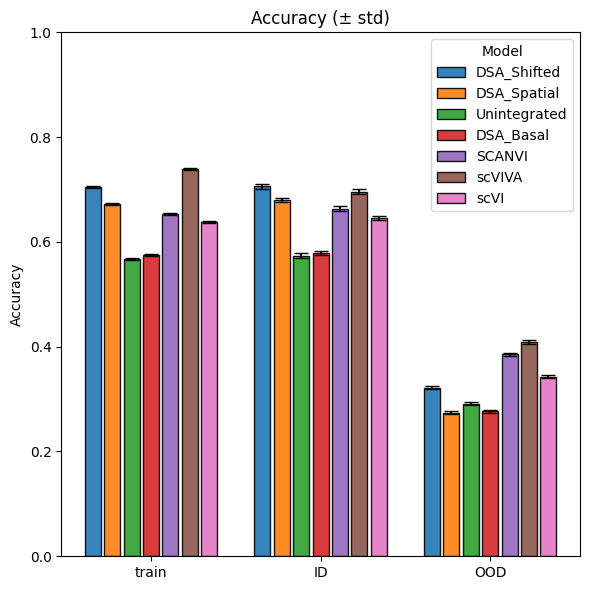

In [19]:
plot_metric_by_split(
    niche_results,
    metric="accuracy",
    title="",
    ylabel="Accuracy",
    # palette=gray_to_red,
    figsize=(6,6)
)

In [20]:
ct_results = benchmark_latents_from_anndata(adata,
                                            label_key=celltype_key,
                                            model_keys=OBSM_KEYS,
                                            n_bootstrap=100)
ct_results.to_csv(f"../results/{dataset_name}_class_ct.csv")

Benchmarking DSA_Shifted...
Benchmarking DSA_Spatial...
Benchmarking Unintegrated...
Benchmarking DSA_Basal...
Benchmarking SCANVI...
Benchmarking scVIVA...
Benchmarking scVI...


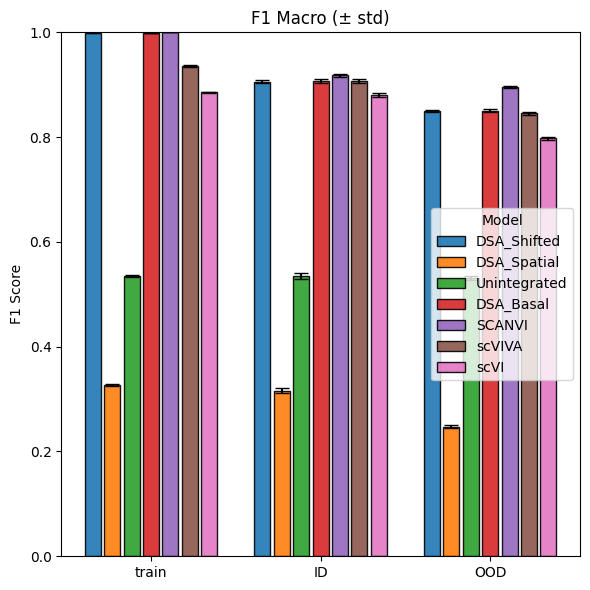

In [21]:
plot_metric_by_split(
    ct_results,
    metric="f1_macro",
    title="",
    ylabel="F1 Score",
    # palette=gray_to_red,
    figsize=(6,6)
)

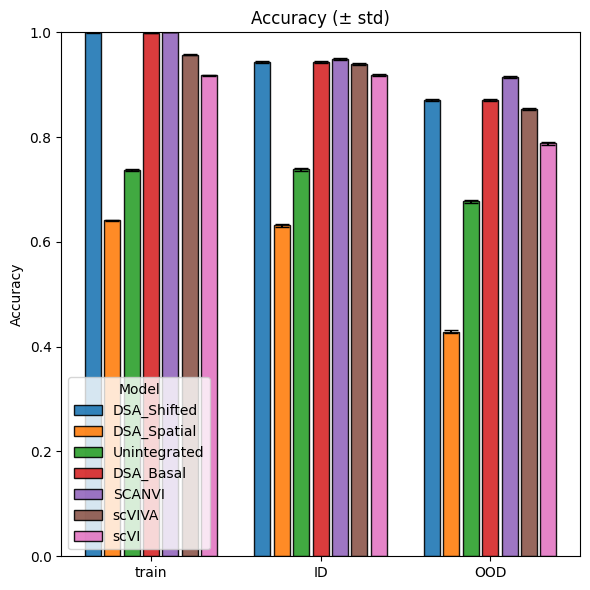

: 

In [ ]:
plot_metric_by_split(
    ct_results,
    metric="accuracy",
    title="",
    ylabel="Accuracy",
    # palette=gray_to_red,
    figsize=(6,6)
)